# V2 Prediction Model

This notebook trains and evaluates supervised temperature prediction models from the v2 object timeline dataset.

The notebook uses the same prepared feature table for LightGBM and XGBoost, compares baseline and tuned settings, and exports tuned test-set prediction CSV files for downstream use.


## Setup

This section imports the project configuration, model helper functions, plotting libraries, and optimization package.

| Item | Purpose |
|---|---|
| `v2_config` | Defines v2 input and output paths. |
| `v2_04_lgbm_temperature` | Provides the shared feature builder and LightGBM training function. |
| `v2_05_xgboost_forecast` | Provides the XGBoost training function. |
| `optuna` | Runs TPE hyperparameter search. |


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import v2_config
from v2_04_lgbm_temperature import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    PEOPLE_CONTEXT_FEATURES,
    build_model_dataset,
    regression_metrics,
    split_by_dates,
    train_lgbm_model,
)
from v2_05_xgboost_forecast import train_forecast_models


## Model Configuration

This section defines the prediction target, forecast horizons, date split, random seed, tuning budget, and output folders.

| Parameter | Current value | Purpose |
|---|---:|---|
| `TEMPERATURE_COLUMN` | `temp_mean_c` | Temperature value used as the source and target variable. |
| `TARGET_MINUTES_LIST` | `[10.0, 20.0]` | Forecast horizons evaluated by the notebook. |
| `OBJECT_ROLE` | `machine` | Limits prediction rows to non-person objects. |
| `TRAIN_DATES` | ['2025-04-23', '2025-04-24', '2025-05-06', '2025-05-09', '2025-05-14', '2025-05-13', '2025-05-15'] |
| `VALID_DATES` | ['2025-04-25', '2025-04-30', '2025-05-01', '2025-05-07'] |
| `TEST_DATES` | ['2025-04-29', '2025-05-02', '2025-05-08', '2025-05-12']|
| `RANDOM_STATE` | `42` | Reproducible model training and TPE sampling. |
| `N_TRIALS` | `50` | Number of TPE trials per model and horizon. |
| `N_ESTIMATORS` | `2000` | Maximum boosting iterations before early stopping. |
| `EARLY_STOPPING_ROUNDS` | `100` | Stops training when validation RMSE does not improve. |


In [2]:
TEMPERATURE_COLUMN = 'temp_mean_c'
TARGET_MINUTES_LIST = [10.0, 20.0]
OBJECT_ROLE = 'machine'

TRAIN_DATES = ['2025-04-23', '2025-04-24', '2025-05-06', '2025-05-09', '2025-05-14', '2025-05-13', '2025-05-15']
VALID_DATES = ['2025-04-25', '2025-04-30', '2025-05-01', '2025-05-07']
TEST_DATES = ['2025-04-29', '2025-05-02', '2025-05-08', '2025-05-12']

RANDOM_STATE = 123
N_TRIALS = 50
TIMEOUT_PER_HORIZON = None
N_ESTIMATORS = 2000
EARLY_STOPPING_ROUNDS = 100

OUTPUT_DIR = v2_config.V2_ROOT_DIR / 'prediction_model'
PREDICTION_OUTPUT_DIR = OUTPUT_DIR / 'predictions'
TABLE_OUTPUT_DIR = OUTPUT_DIR / 'tables'
FIGURE_OUTPUT_DIR = OUTPUT_DIR / 'figures'
for path in [OUTPUT_DIR, PREDICTION_OUTPUT_DIR, TABLE_OUTPUT_DIR, FIGURE_OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ['LGBM', 'XGBoost']
SETTING_ORDER = ['baseline', 'tuned']
HORIZON_COLORS = {10.0: '#1f77b4', 20.0: '#ff7f0e'}
MODEL_COLORS = {'LGBM': '#4e79a7', 'XGBoost': '#f28e2b'}
MODEL_HORIZON_COLORS = {
    ('LGBM', 10.0): '#d62728',
    ('LGBM', 20.0): '#1f77b4',
    ('XGBoost', 10.0): '#2ca02c',
    ('XGBoost', 20.0): '#9467bd',
}


## Dataset Summary

This section builds one supervised-learning table for each forecast horizon and applies the date split.

Each row represents one object at one source timestamp. The target is the nearest available future temperature after the requested horizon, constrained by the target matching tolerance in the shared feature builder.

| Output | Meaning |
|---|---|
| `model_df` | Full feature table for one horizon. |
| `train_df` | Rows from `TRAIN_DATES`. |
| `valid_df` | Rows from `VALID_DATES`. |
| `test_df` | Rows from `TEST_DATES`. |
| `feature_columns` | Features passed into both models. |


In [3]:
def horizon_tag(target_minutes):
    return f'{int(target_minutes):02d}min' if float(target_minutes).is_integer() else f'{target_minutes:g}min'.replace('.', 'p')


def build_split_for_horizon(target_minutes):
    model_df, feature_columns = build_model_dataset(
        timeline_csv=v2_config.V2_OBJECT_TIMELINE_CSV,
        temperature_column=TEMPERATURE_COLUMN,
        target_horizon=1,
        target_minutes=target_minutes,
        object_role=OBJECT_ROLE,
    )
    model_df = model_df.copy()
    model_df['target_minutes'] = float(target_minutes)
    model_df['horizon'] = horizon_tag(target_minutes)
    train_df, valid_df, test_df = split_by_dates(model_df, TRAIN_DATES, VALID_DATES, TEST_DATES)
    return {
        'target_minutes': float(target_minutes),
        'horizon': horizon_tag(target_minutes),
        'model_df': model_df,
        'feature_columns': feature_columns,
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
    }


datasets = {target_minutes: build_split_for_horizon(target_minutes) for target_minutes in TARGET_MINUTES_LIST}
feature_columns = datasets[TARGET_MINUTES_LIST[0]]['feature_columns']

summary_rows = []
for target_minutes, data in datasets.items():
    for split_name in ['train', 'valid', 'test']:
        split_df = data[f'{split_name}_df']
        summary_rows.append({
            'horizon': data['horizon'],
            'split': split_name,
            'rows': len(split_df),
            'objects': split_df['object_id'].nunique(),
            'dates': ', '.join(str(date) for date in sorted(split_df['timestamp_dt'].dt.date.unique())),
        })

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)
print(f'features used by both models: {len(feature_columns)}')
display(pd.DataFrame({'feature': feature_columns}))


,horizon,split,rows,objects,dates
0,10min,train,23408,13,"2025-04-23, 2025-04-24, 2025-05-06, 2025-05-09..."
1,10min,valid,14771,12,"2025-04-25, 2025-04-30, 2025-05-01, 2025-05-07"
2,10min,test,16246,12,"2025-04-29, 2025-05-02, 2025-05-08, 2025-05-12"
3,20min,train,22705,13,"2025-04-23, 2025-04-24, 2025-05-06, 2025-05-09..."
4,20min,valid,14377,12,"2025-04-25, 2025-04-30, 2025-05-01, 2025-05-07"
5,20min,test,15751,12,"2025-04-29, 2025-05-02, 2025-05-08, 2025-05-12"


features used by both models: 55


,feature
0,object_id
1,display_x
2,display_y
3,hour
4,minute
5,day_of_week
6,source_temp
7,people_count_total
8,people_count_within_1m
9,people_count_within_2m


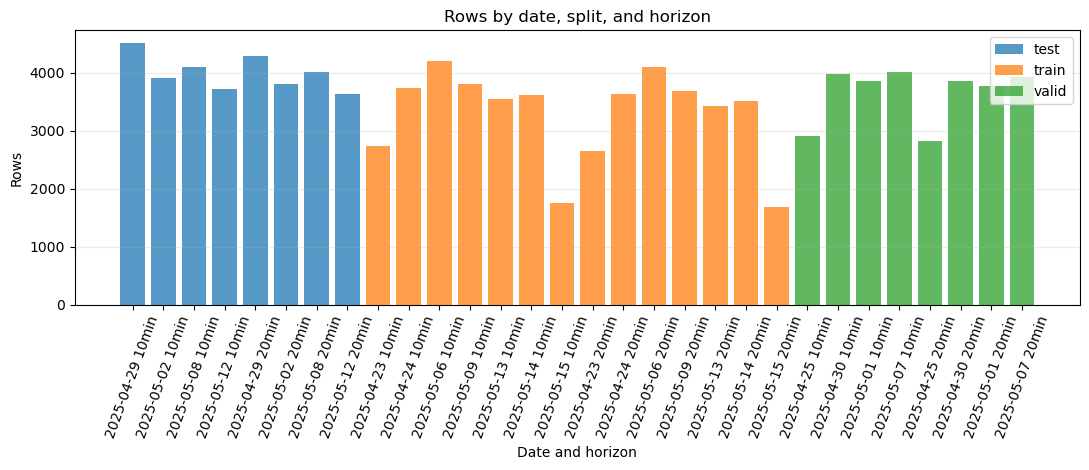

In [4]:
# row counts by target date and horizon.
date_rows = []
for target_minutes, data in datasets.items():
    for split_name in ['train', 'valid', 'test']:
        part = data[f'{split_name}_df'].copy()
        counts = part.groupby(part['timestamp_dt'].dt.date).size().reset_index(name='rows')
        counts = counts.rename(columns={'timestamp_dt': 'date'})
        counts['split'] = split_name
        counts['horizon'] = data['horizon']
        date_rows.append(counts)

date_distribution = pd.concat(date_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(11, 4.8))
for split_name, split_df in date_distribution.groupby('split'):
    ax.bar(
        split_df['date'].astype(str) + ' ' + split_df['horizon'],
        split_df['rows'],
        alpha=0.75,
        label=split_name,
    )
ax.set_title('Rows by date, split, and horizon')
ax.set_xlabel('Date and horizon')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()


## Training Functions

This section defines the baseline settings, TPE search spaces, model wrappers, prediction table format, metric calculation, learning-curve extraction, and feature-importance extraction.

| Parameter group | Parameters | Purpose |
|---|---|---|
| LightGBM baseline | `n_estimators`, `learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree` | Fixed starting point for LightGBM comparison. |
| XGBoost baseline | `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `early_stopping_rounds` | Fixed starting point for XGBoost comparison. |
| TPE objective | validation RMSE | Selects the parameter set with the lowest validation error. |
| Prediction table | object id, timestamp, XY position, source temperature, target temperature, prediction, error | Defines the common schema used by all later plots and CSV exports. |


In [5]:
LGBM_BASELINE_PARAMS = {
    'n_estimators': N_ESTIMATORS,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
}

XGBOOST_BASELINE_PARAMS = {
    'n_estimators': N_ESTIMATORS,
    'learning_rate': 0.03,
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
}


def lgbm_search_params(trial):
    return {
        'n_estimators': N_ESTIMATORS,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 120),
        'subsample': trial.suggest_float('subsample', 0.60, 1.00),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
    }


def xgboost_search_params(trial):
    return {
        'n_estimators': N_ESTIMATORS,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 12.0),
        'subsample': trial.suggest_float('subsample', 0.60, 1.00),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    }


def train_lgbm(train_df, valid_df, feature_columns, params):
    return train_lgbm_model(
        train_df,
        valid_df,
        feature_columns,
        random_state=RANDOM_STATE,
        model_params=params,
    )


def train_xgboost(train_df, valid_df, feature_columns, params):
    models, evals_result = train_forecast_models(
        train_df,
        valid_df,
        feature_columns,
        random_state=RANDOM_STATE,
        model_params=params,
    )
    return models['mean'], evals_result


def predict_split_table(model, data, feature_columns, model_name, setting, target_minutes):
    outputs = []
    for split_name in ['train', 'valid', 'test']:
        split_df = data[f'{split_name}_df'].copy()
        prediction = model.predict(split_df[feature_columns])
        part = split_df[[
            'object_id', 'label', 'timestamp', 'timestamp_dt', 'target_timestamp',
            'display_x', 'display_y', 'source_temp', 'target_temp',
            'target_minutes_ahead', *PEOPLE_CONTEXT_FEATURES,
        ]].copy()
        part['model'] = model_name
        part['setting'] = setting
        part['target_minutes'] = float(target_minutes)
        part['horizon'] = horizon_tag(target_minutes)
        part['split'] = split_name
        part['prediction'] = prediction
        part['error'] = part['prediction'] - part['target_temp']
        outputs.append(part)
    return pd.concat(outputs, ignore_index=True)


def metric_summary(df, group_columns):
    rows = []
    for keys, group in df.groupby(group_columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        metrics = regression_metrics(group['target_temp'], group['prediction'])
        abs_error = (group['prediction'] - group['target_temp']).abs()
        rel_error = abs_error / group['target_temp'].abs().replace(0, np.nan)
        rows.append({
            **dict(zip(group_columns, keys)),
            'rows': len(group),
            'mae': metrics['mae'],
            'rmse': metrics['rmse'],
            'r2': metrics['r2'],
            'mean_error': float((group['prediction'] - group['target_temp']).mean()),
            'mape_pct': float(rel_error.mean() * 100),
            'within_10pct': float((rel_error <= 0.10).mean()),
            'within_15pct': float((rel_error <= 0.15).mean()),
        })
    return pd.DataFrame(rows)


def eval_curve_frame(evals_result, model_name, setting, target_minutes):
    rows = []
    for split_name, metrics in evals_result.items():
        rmse_values = metrics.get('rmse') or []
        for iteration, rmse in enumerate(rmse_values, start=1):
            rows.append({
                'model': model_name,
                'setting': setting,
                'target_minutes': float(target_minutes),
                'horizon': horizon_tag(target_minutes),
                'split': split_name,
                'iteration': iteration,
                'rmse': float(rmse),
            })
    return pd.DataFrame(rows)


def feature_importance_frame(model, feature_columns, model_name, setting, target_minutes):
    return pd.DataFrame({
        'model': model_name,
        'setting': setting,
        'target_minutes': float(target_minutes),
        'horizon': horizon_tag(target_minutes),
        'feature': feature_columns,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)


## Baseline Models

This section trains fixed-parameter LightGBM and XGBoost models for each forecast horizon.

The baseline results provide a reference point before hyperparameter tuning.


In [6]:
all_results = {}
prediction_parts = []
learning_curve_parts = []
importance_parts = []
metric_parts = []
parameter_rows = []

for target_minutes, data in datasets.items():
    for model_name, train_func, params in [
        ('LGBM', train_lgbm, LGBM_BASELINE_PARAMS),
        ('XGBoost', train_xgboost, XGBOOST_BASELINE_PARAMS),
    ]:
        print(f'training {model_name} baseline {target_minutes:g} min')
        model, evals_result = train_func(data['train_df'], data['valid_df'], data['feature_columns'], params)
        predictions = predict_split_table(model, data, data['feature_columns'], model_name, 'baseline', target_minutes)
        metrics = metric_summary(predictions, ['model', 'setting', 'target_minutes', 'horizon', 'split'])
        all_results[(model_name, 'baseline', target_minutes)] = {
            'model': model,
            'evals_result': evals_result,
            'predictions': predictions,
            'metrics': metrics,
            'params': params,
            'feature_columns': data['feature_columns'],
        }
        prediction_parts.append(predictions)
        metric_parts.append(metrics)
        learning_curve_parts.append(eval_curve_frame(evals_result, model_name, 'baseline', target_minutes))
        importance_parts.append(feature_importance_frame(model, data['feature_columns'], model_name, 'baseline', target_minutes))
        parameter_rows.append({'model': model_name, 'setting': 'baseline', 'target_minutes': target_minutes, 'horizon': horizon_tag(target_minutes), **params})

baseline_metrics = pd.concat(metric_parts, ignore_index=True).query("setting == 'baseline'")
display(baseline_metrics)


training LGBM baseline 10 min
training XGBoost baseline 10 min
training LGBM baseline 20 min
training XGBoost baseline 20 min


,model,setting,target_minutes,horizon,split,rows,mae,rmse,r2,mean_error,mape_pct,within_10pct,within_15pct
0,LGBM,baseline,10.0,10min,test,16246,0.481596,0.696363,0.881451,-0.029524,1.955305,0.990952,0.998338
1,LGBM,baseline,10.0,10min,train,23408,0.410879,0.616121,0.916208,-0.000012,1.690527,0.993720,0.999017
2,LGBM,baseline,10.0,10min,valid,14771,0.519054,0.733622,0.821192,0.094683,2.212519,0.990048,0.998375
3,XGBoost,baseline,10.0,10min,test,16246,0.480374,0.693782,0.882328,-0.038655,1.948770,0.991259,0.998523
4,XGBoost,baseline,10.0,10min,train,23408,0.404379,0.597831,0.921109,-0.000598,1.664390,0.994788,0.999316
5,XGBoost,baseline,10.0,10min,valid,14771,0.524225,0.738722,0.818697,0.103753,2.235660,0.990657,0.998307
6,LGBM,baseline,20.0,20min,test,15751,0.572097,0.803975,0.834042,-0.042108,2.321005,0.988572,0.997524
7,LGBM,baseline,20.0,20min,train,22705,0.497812,0.713700,0.884694,-0.000015,2.049869,0.990751,0.998503
8,LGBM,baseline,20.0,20min,valid,14377,0.633037,0.876353,0.735561,0.146810,2.699496,0.981776,0.996244
9,XGBoost,baseline,20.0,20min,test,15751,0.570832,0.803968,0.834045,-0.047327,2.314038,0.988636,0.997460


## TPE Parameter Search

This section runs Optuna TPE search independently for each model and forecast horizon.

| Model | Tuned parameter | Search range | Purpose |
|---|---|---:|---|
| LightGBM | `learning_rate` | 0.005 to 0.08 | Controls the contribution of each boosting iteration. |
| LightGBM | `num_leaves` | 15 to 127 | Controls leaf-wise tree complexity. |
| LightGBM | `min_child_samples` | 10 to 120 | Sets the minimum rows required in a leaf. |
| LightGBM | `subsample` | 0.60 to 1.00 | Samples rows per tree to reduce overfitting. |
| LightGBM | `colsample_bytree` | 0.60 to 1.00 | Samples features per tree to reduce overfitting. |
| XGBoost | `learning_rate` | 0.005 to 0.08 | Controls the contribution of each boosting iteration. |
| XGBoost | `max_depth` | 3 to 10 | Controls level-wise tree depth. |
| XGBoost | `min_child_weight` | 1.0 to 12.0 | Requires enough sample weight before splitting. |
| XGBoost | `subsample` | 0.60 to 1.00 | Samples rows per tree to reduce overfitting. |
| XGBoost | `colsample_bytree` | 0.60 to 1.00 | Samples features per tree to reduce overfitting. |


In [ ]:
try:
    import optuna
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Missing optuna. Install optuna in the active environment before running this cell.') from exc


def tune_model(model_name, target_minutes, data):
    train_func = train_lgbm if model_name == 'LGBM' else train_xgboost
    search_func = lgbm_search_params if model_name == 'LGBM' else xgboost_search_params

    def objective(trial):
        params = search_func(trial)
        model, _ = train_func(data['train_df'], data['valid_df'], data['feature_columns'], params)
        valid_prediction = model.predict(data['valid_df'][data['feature_columns']])
        return regression_metrics(data['valid_df']['target_temp'], valid_prediction)['rmse']

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_PER_HORIZON, show_progress_bar=True)
    return study


studies = {}
best_params_by_model = {}
for target_minutes, data in datasets.items():
    for model_name in MODEL_ORDER:
        print(f'tuning {model_name} {target_minutes:g} min')
        study = tune_model(model_name, target_minutes, data)
        studies[(model_name, target_minutes)] = study
        best_params_by_model[(model_name, target_minutes)] = study.best_params

best_params_rows = []
for (model_name, target_minutes), study in studies.items():
    row = {
        'model': model_name,
        'target_minutes': float(target_minutes),
        'horizon': horizon_tag(target_minutes),
        'best_valid_rmse': study.best_value,
    }
    row.update(study.best_params)
    best_params_rows.append(row)

best_params_table = pd.DataFrame(best_params_rows).sort_values(['model', 'target_minutes'])
best_params_json = TABLE_OUTPUT_DIR / 'v2_06_best_tpe_params.json'
best_params_json.write_text(json.dumps(best_params_rows, indent=2), encoding='utf-8')
display(best_params_table)
print('saved:', best_params_json)


/opt/miniconda3/envs/itp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-01 20:24:46,453] A new study created in memory with name: no-name-b16c5c8a-7691-4ecb-8b66-4c67b55078e9


tuning LGBM 10 min


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.736107:   2%|▏         | 1/50 [00:01<01:12,  1.48s/it]

[I 2026-06-01 20:24:47,947] Trial 0 finished with value: 0.7361069653972625 and parameters: {'learning_rate': 0.03448279561431617, 'num_leaves': 47, 'min_child_samples': 35, 'subsample': 0.8205259076331565, 'colsample_bytree': 0.8877875879142252}. Best is trial 0 with value: 0.7361069653972625.


...

[I 2026-06-01 20:31:02,977] Trial 24 finished with value: 0.8726663433537505 and parameters: {'learning_rate': 0.018278157074884525, 'max_depth': 5, 'min_child_weight': 6.756659142034515, 'subsample': 0.6719259352727633, 'colsample_bytree': 0.9035948602951613}. Best is trial 23 with value: 0.8638962364195862.


Best trial: 23. Best value: 0.863896:  52%|█████▏    | 26/50 [00:44<00:49,  2.04s/it]

[I 2026-06-01 20:31:06,810] Trial 25 finished with value: 0.865523740501092 and parameters: {'learning_rate': 0.007828420125278117, 'max_depth': 4, 'min_child_weight': 8.621149084705197, 'subsample': 0.649168811424942, 'colsample_bytree': 0.9363087679669442}. Best is trial 23 with value: 0.8638962364195862.


Best trial: 23. Best value: 0.863896:  54%|█████▍    | 27/50 [00:46<00:47,  2.05s/it]

[I 2026-06-01 20:31:08,893] Trial 26 finished with value: 0.8659565152758911 and parameters: {'learning_rate': 0.015346604527769809, 'max_depth': 3, 'min_child_weight': 6.281837751634922, 'subsample': 0.6368579541584546, 'colsample_bytree': 0.8478538968335477}. Best is trial 23 with value: 0.8638962364195862.


## Tuned Models

This section retrains LightGBM and XGBoost using the best TPE parameters for each horizon.

The trained tuned models generate the final prediction tables, metrics, learning curves, and feature-importance results used in the remaining sections.


In [ ]:
for target_minutes, data in datasets.items():
    for model_name, train_func, baseline_params in [
        ('LGBM', train_lgbm, LGBM_BASELINE_PARAMS),
        ('XGBoost', train_xgboost, XGBOOST_BASELINE_PARAMS),
    ]:
        tuned_params = baseline_params.copy()
        tuned_params.update(best_params_by_model[(model_name, target_minutes)])
        if model_name == 'XGBoost':
            tuned_params['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
        print(f'training {model_name} tuned {target_minutes:g} min')
        model, evals_result = train_func(data['train_df'], data['valid_df'], data['feature_columns'], tuned_params)
        predictions = predict_split_table(model, data, data['feature_columns'], model_name, 'tuned', target_minutes)
        metrics = metric_summary(predictions, ['model', 'setting', 'target_minutes', 'horizon', 'split'])
        all_results[(model_name, 'tuned', target_minutes)] = {
            'model': model,
            'evals_result': evals_result,
            'predictions': predictions,
            'metrics': metrics,
            'params': tuned_params,
            'feature_columns': data['feature_columns'],
        }
        prediction_parts.append(predictions)
        metric_parts.append(metrics)
        learning_curve_parts.append(eval_curve_frame(evals_result, model_name, 'tuned', target_minutes))
        importance_parts.append(feature_importance_frame(model, data['feature_columns'], model_name, 'tuned', target_minutes))
        parameter_rows.append({'model': model_name, 'setting': 'tuned', 'target_minutes': target_minutes, 'horizon': horizon_tag(target_minutes), **tuned_params})

all_predictions = pd.concat(prediction_parts, ignore_index=True)
all_metrics = pd.concat(metric_parts, ignore_index=True)
learning_curves = pd.concat(learning_curve_parts, ignore_index=True)
feature_importance = pd.concat(importance_parts, ignore_index=True)
final_parameter_table = pd.DataFrame(parameter_rows).sort_values(['model', 'target_minutes', 'setting'])

display(all_metrics.sort_values(['model', 'target_minutes', 'setting', 'split']))
display(final_parameter_table)


training LGBM tuned 10 min
training XGBoost tuned 10 min
training LGBM tuned 20 min
training XGBoost tuned 20 min


,model,setting,target_minutes,horizon,split,rows,mae,rmse,r2,mean_error,mape_pct,within_10pct,within_15pct
0,LGBM,baseline,10.0,10min,test,16246,0.481596,0.696363,0.881451,-0.029524,1.955305,0.990952,0.998338
1,LGBM,baseline,10.0,10min,train,23408,0.410879,0.616121,0.916208,-0.000012,1.690527,0.993720,0.999017
2,LGBM,baseline,10.0,10min,valid,14771,0.519054,0.733622,0.821192,0.094683,2.212519,0.990048,0.998375
12,LGBM,tuned,10.0,10min,test,16246,0.477005,0.693108,0.882557,-0.032721,1.936553,0.991259,0.997969
13,LGBM,tuned,10.0,10min,train,23408,0.423141,0.654028,0.905581,-0.000031,1.738575,0.991370,0.998248
14,LGBM,tuned,10.0,10min,valid,14771,0.514906,0.729084,0.823397,0.091748,2.195417,0.990183,0.998375
6,LGBM,baseline,20.0,20min,test,15751,0.572097,0.803975,0.834042,-0.042108,2.321005,0.988572,0.997524
7,LGBM,baseline,20.0,20min,train,22705,0.497812,0.713700,0.884694,-0.000015,2.049869,0.990751,0.998503
8,LGBM,baseline,20.0,20min,valid,14377,0.633037,0.876353,0.735561,0.146810,2.699496,0.981776,0.996244
18,LGBM,tuned,20.0,20min,test,15751,0.567951,0.800572,0.835444,-0.039926,2.302386,0.988763,0.997207


,model,setting,target_minutes,horizon,n_estimators,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,max_depth,min_child_weight,early_stopping_rounds
0,LGBM,baseline,10.0,10min,2000,0.030000,31.0,20.0,0.850000,0.850000,NaN,NaN,NaN
4,LGBM,tuned,10.0,10min,2000,0.026712,27.0,82.0,0.879729,0.681351,NaN,NaN,NaN
2,LGBM,baseline,20.0,20min,2000,0.030000,31.0,20.0,0.850000,0.850000,NaN,NaN,NaN
6,LGBM,tuned,20.0,20min,2000,0.005019,18.0,99.0,0.640470,0.638398,NaN,NaN,NaN
1,XGBoost,baseline,10.0,10min,2000,0.030000,NaN,NaN,0.850000,0.850000,6.0,3.000000,100.0
5,XGBoost,tuned,10.0,10min,2000,0.024370,NaN,NaN,0.618749,0.634501,4.0,4.264542,100.0
3,XGBoost,baseline,20.0,20min,2000,0.030000,NaN,NaN,0.850000,0.850000,6.0,3.000000,100.0
7,XGBoost,tuned,20.0,20min,2000,0.049153,NaN,NaN,0.638072,0.840402,4.0,7.560549,100.0


## Prediction Outputs

This section exports only tuned test-set prediction results and supporting summary tables.

| Output file | Content | Use |
|---|---|---|
| `v2_06_tuned_test_predictions_10min.csv` | Long-format 10 min tuned predictions with XY position and error. | External use for 10 min prediction results. |
| `v2_06_tuned_test_predictions_20min.csv` | Long-format 20 min tuned predictions with XY position and error. | External use for 20 min prediction results. |
| `v2_06_tuned_test_predictions_wide.csv` | One row per object and target timestamp, with tuned model predictions in separate columns. | Direct comparison between models and horizons. |
| `v2_06_model_metrics.csv` | Metrics for train, validation, and test splits. | Record of model performance. |
| `v2_06_final_parameter_table.csv` | Baseline and tuned parameter settings. | Record of model configuration. |


In [ ]:
# save only the test-set prediction outputs for external use.
tuned_test_predictions = all_predictions.query("setting == 'tuned' and split == 'test'").copy()
metadata_columns = [
    'object_id', 'label', 'timestamp', 'timestamp_dt', 'target_timestamp',
    'display_x', 'display_y', 'source_temp', 'target_temp', 'target_minutes_ahead',
    'model', 'setting', 'target_minutes', 'horizon', 'split', 'prediction', 'error',
]
for target_minutes, part in tuned_test_predictions.groupby('target_minutes'):
    output_csv = PREDICTION_OUTPUT_DIR / f'v2_06_tuned_test_predictions_{horizon_tag(target_minutes)}.csv'
    part[metadata_columns].to_csv(output_csv, index=False)
    print('saved:', output_csv, 'rows:', len(part))

wide_index = ['object_id', 'label', 'target_timestamp', 'display_x', 'display_y', 'target_temp']
wide_predictions = (
    tuned_test_predictions
    .pivot_table(index=wide_index, columns=['model', 'target_minutes'], values='prediction', aggfunc='median')
)
wide_predictions.columns = [f'{model.lower()}_{horizon_tag(target_minutes)}_prediction' for model, target_minutes in wide_predictions.columns]
wide_predictions = wide_predictions.reset_index()
wide_csv = PREDICTION_OUTPUT_DIR / 'v2_06_tuned_test_predictions_wide.csv'
wide_predictions.to_csv(wide_csv, index=False)
metrics_csv = TABLE_OUTPUT_DIR / 'v2_06_model_metrics.csv'
params_csv = TABLE_OUTPUT_DIR / 'v2_06_final_parameter_table.csv'
all_metrics.to_csv(metrics_csv, index=False)
final_parameter_table.to_csv(params_csv, index=False)
print('saved:', wide_csv)
print('saved:', metrics_csv)
print('saved:', params_csv)


saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/predictions/v2_06_tuned_test_predictions_10min.csv rows: 32492
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/predictions/v2_06_tuned_test_predictions_20min.csv rows: 31502
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/predictions/v2_06_tuned_test_predictions_wide.csv
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/tables/v2_06_model_metrics.csv
saved: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/prediction_model/tables/v2_06_final_parameter_table.csv


## Train and Validation Loss

This section plots boosting RMSE over training iterations for tuned models.

The curves are used to check whether validation loss stops improving and whether training loss continues decreasing while validation loss plateaus or rises.


In [ ]:
plot_curves = learning_curves[learning_curves['setting'] == 'tuned'].copy()
fig, ax = plt.subplots(figsize=(11, 5.5))
for (model_name, target_minutes, split_name), part in plot_curves.groupby(['model', 'target_minutes', 'split']):
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    linestyle = '-' if split_name == 'valid' else '--'
    alpha = 0.95 if split_name == 'valid' else 0.55
    ax.plot(
        part['iteration'],
        part['rmse'],
        color=color,
        linestyle=linestyle,
        alpha=alpha,
        label=f'{model_name} {target_minutes:g} min {split_name}',
    )
ax.set_title('Train and validation RMSE by model and horizon')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('RMSE (C)')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()


## RMSE Comparison

This section compares tuned test RMSE across model type and forecast horizon.

| Dimension | Values |
|---|---|
| Model | LightGBM, XGBoost |
| Setting | tuned only |
| Horizon | 10 min, 20 min |


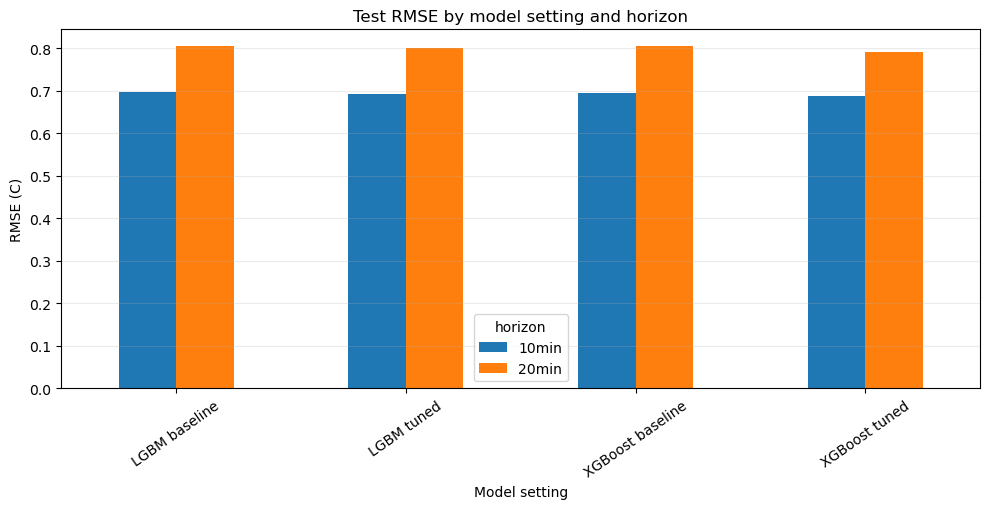

In [ ]:
test_metrics_all = all_metrics[all_metrics['split'] == 'test'].copy()
test_metrics = test_metrics_all[test_metrics_all['setting'] == 'tuned'].copy()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
plot_df = test_metrics.pivot_table(index='model', columns='horizon', values='rmse')
plot_df = plot_df.reindex(MODEL_ORDER)
plot_df.plot(kind='bar', ax=ax)
ax.set_title('Tuned test RMSE by model and horizon')
ax.set_xlabel('Model')
ax.set_ylabel('RMSE (C)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()


## TPE Parameters

This section displays the best TPE parameters, the final parameter table, and the validation RMSE observed during each TPE trial.

The trial plot uses four colors for the four trained model-horizon settings: LGBM 10 min, LGBM 20 min, XGBoost 10 min, and XGBoost 20 min.


,model,target_minutes,horizon,best_valid_rmse,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,max_depth,min_child_weight
0,LGBM,10.0,10min,0.729084,0.026712,27.0,82.0,0.879729,0.681351,NaN,NaN
2,LGBM,20.0,20min,0.863817,0.005019,18.0,99.0,0.640470,0.638398,NaN,NaN
1,XGBoost,10.0,10min,0.728040,0.024370,NaN,NaN,0.618749,0.634501,4.0,4.264542
3,XGBoost,20.0,20min,0.863847,0.049153,NaN,NaN,0.638072,0.840402,4.0,7.560549


,model,setting,target_minutes,horizon,n_estimators,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,max_depth,min_child_weight,early_stopping_rounds
0,LGBM,baseline,10.0,10min,2000,0.030000,31.0,20.0,0.850000,0.850000,NaN,NaN,NaN
4,LGBM,tuned,10.0,10min,2000,0.026712,27.0,82.0,0.879729,0.681351,NaN,NaN,NaN
2,LGBM,baseline,20.0,20min,2000,0.030000,31.0,20.0,0.850000,0.850000,NaN,NaN,NaN
6,LGBM,tuned,20.0,20min,2000,0.005019,18.0,99.0,0.640470,0.638398,NaN,NaN,NaN
1,XGBoost,baseline,10.0,10min,2000,0.030000,NaN,NaN,0.850000,0.850000,6.0,3.000000,100.0
5,XGBoost,tuned,10.0,10min,2000,0.024370,NaN,NaN,0.618749,0.634501,4.0,4.264542,100.0
3,XGBoost,baseline,20.0,20min,2000,0.030000,NaN,NaN,0.850000,0.850000,6.0,3.000000,100.0
7,XGBoost,tuned,20.0,20min,2000,0.049153,NaN,NaN,0.638072,0.840402,4.0,7.560549,100.0


,model,target_minutes,horizon,trial,valid_rmse,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,max_depth,min_child_weight
0,LGBM,10.0,10min,0,0.736107,0.034483,47.0,35.0,0.820526,0.887788,NaN,NaN
1,LGBM,10.0,10min,1,0.739601,0.016160,125.0,86.0,0.792373,0.756847,NaN,NaN
2,LGBM,10.0,10min,2,0.738116,0.012948,97.0,58.0,0.623871,0.759218,NaN,NaN
3,LGBM,10.0,10min,3,0.736198,0.038691,35.0,29.0,0.812621,0.812731,NaN,NaN
4,LGBM,10.0,10min,4,0.739126,0.029031,110.0,90.0,0.844409,0.888977,NaN,NaN


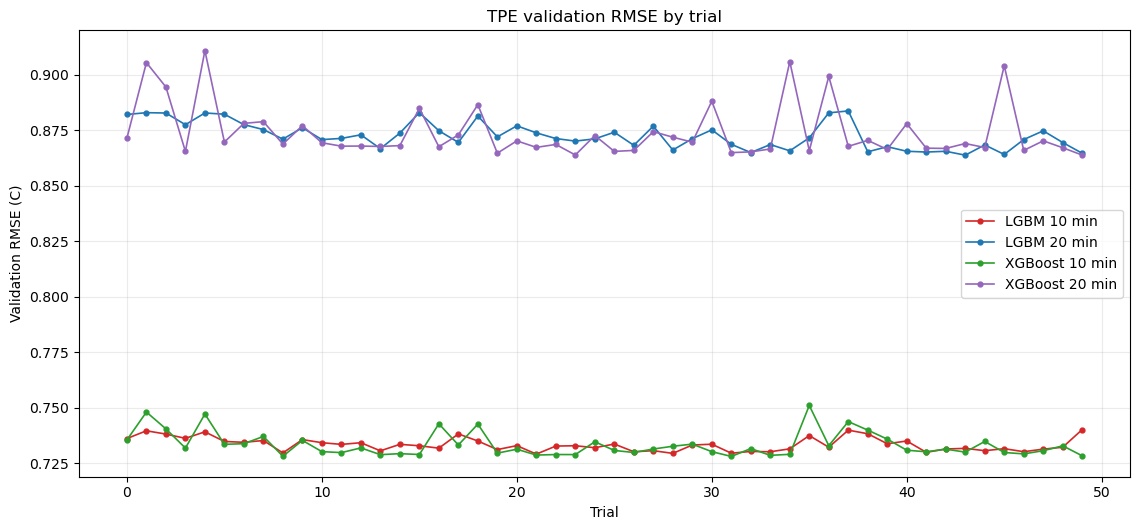

In [ ]:
display(best_params_table)
display(final_parameter_table)

tpe_trial_rows = []
for (model_name, target_minutes), study in studies.items():
    for trial in study.trials:
        if trial.value is None:
            continue
        row = {
            'model': model_name,
            'target_minutes': float(target_minutes),
            'horizon': horizon_tag(target_minutes),
            'trial': trial.number,
            'valid_rmse': float(trial.value),
        }
        for param_name, param_value in trial.params.items():
            row[param_name] = param_value
        tpe_trial_rows.append(row)

tpe_trials = pd.DataFrame(tpe_trial_rows)
display(tpe_trials.sort_values(['model', 'target_minutes', 'trial']).head())

fig, ax = plt.subplots(figsize=(11.5, 5.4))
for (model_name, target_minutes), part in tpe_trials.groupby(['model', 'target_minutes']):
    part = part.sort_values('trial')
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    ax.plot(
        part['trial'],
        part['valid_rmse'],
        marker='o',
        markersize=3.5,
        linewidth=1.2,
        color=color,
        label=f'{model_name} {target_minutes:g} min',
    )
ax.set_title('TPE validation RMSE by trial')
ax.set_xlabel('Trial')
ax.set_ylabel('Validation RMSE (C)')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()


for (model_name, target_minutes), part in tpe_trials.groupby(['model', 'target_minutes']):
    part = part.sort_values('trial').copy()
    part['best_so_far'] = part['valid_rmse'].cummin()
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.plot(
        part['trial'],
        part['valid_rmse'],
        marker='o',
        markersize=4,
        linewidth=1.0,
        color=color,
        alpha=0.55,
        label='trial valid RMSE',
    )
    ax.plot(
        part['trial'],
        part['best_so_far'],
        color='red',
        linewidth=2.0,
        label='best so far',
    )
    ax.set_title(f'{target_minutes:g}min {model_name} tuning history')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Validation RMSE (C)')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    fig.tight_layout()


## Feature Importance

This section shows the most influential model features for the tuned models.

The table keeps all feature-importance values, while the plot displays the top features for readability.


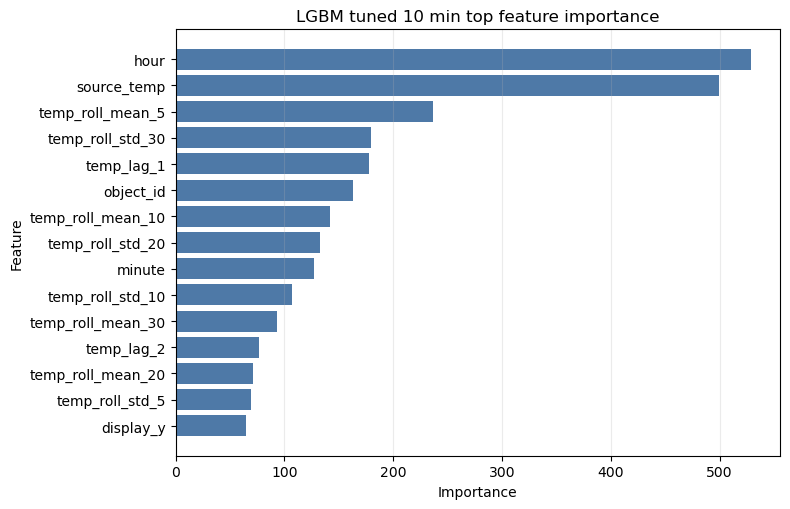

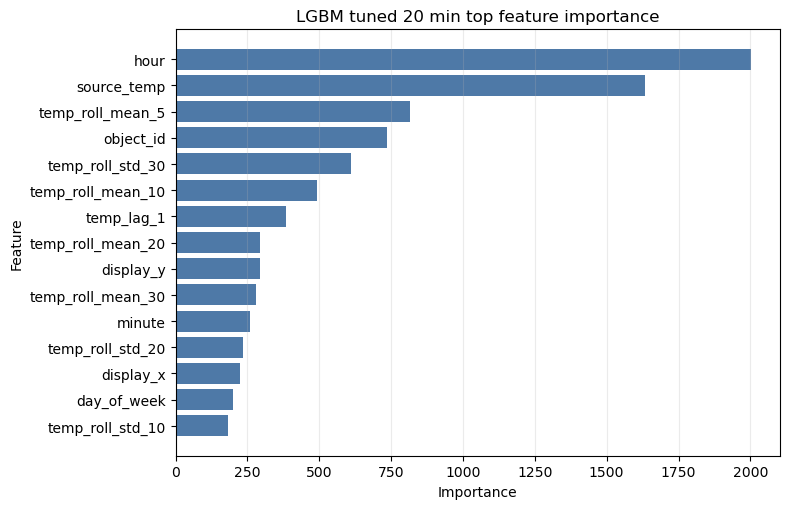

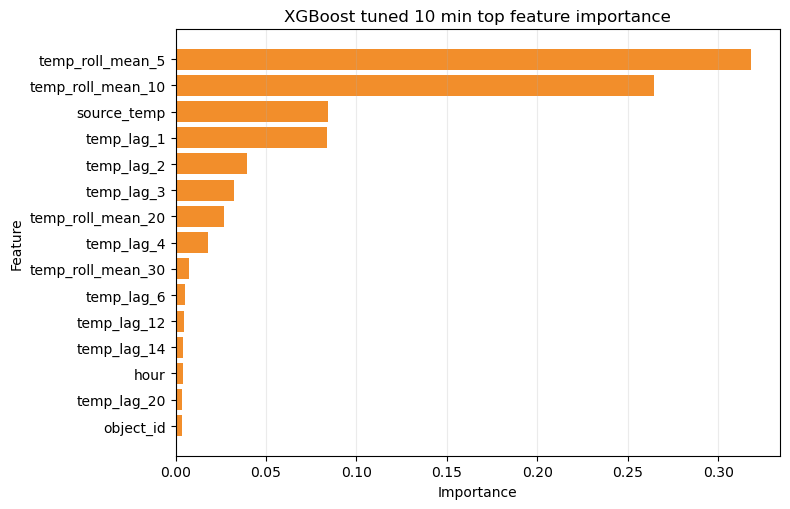

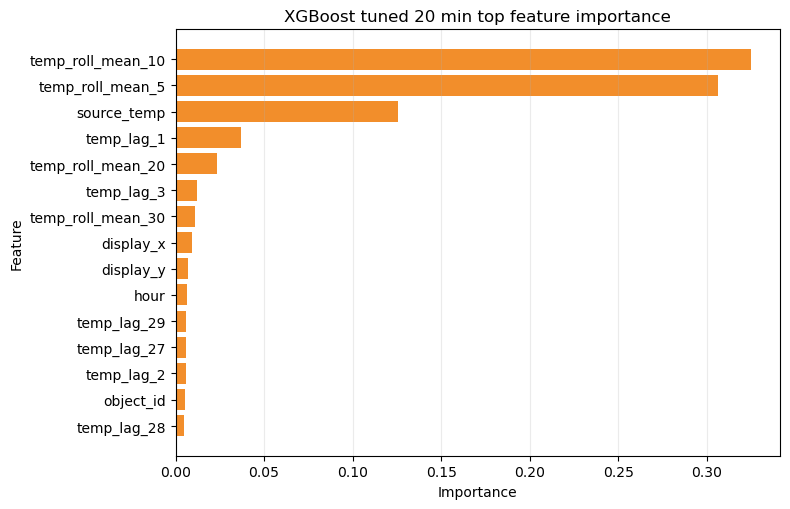

In [ ]:
TOP_FEATURES = 15
importance_plot = feature_importance[feature_importance['setting'] == 'tuned'].copy()
for (model_name, target_minutes), part in importance_plot.groupby(['model', 'target_minutes']):
    top = part.sort_values('importance', ascending=False).head(TOP_FEATURES).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    ax.barh(top['feature'], top['importance'], color=MODEL_COLORS.get(model_name, '#777777'))
    ax.set_title(f'{model_name} tuned {target_minutes:g} min top feature importance')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()


## Prediction Scatter

This section plots predicted temperature against ground truth temperature for tuned models.

The diagonal line represents perfect prediction. The colored relative-error bounds show ±10% and ±15% ranges from the ground truth value. The figure is wider than a square parity plot so dense prediction regions and legends remain readable.


In [ ]:
def add_relative_error_bounds(ax, line_x, target_minutes):
    color = HORIZON_COLORS.get(float(target_minutes), '#777777')
    ax.plot(line_x, line_x * 1.10, color=color, linestyle='-', linewidth=1.0, label=f'{target_minutes:g} min 10% relative error')
    ax.plot(line_x, line_x * 0.90, color=color, linestyle='-', linewidth=1.0)
    ax.plot(line_x, line_x * 1.15, color=color, linestyle='--', linewidth=1.0, label=f'{target_minutes:g} min 15% relative error')
    ax.plot(line_x, line_x * 0.85, color=color, linestyle='--', linewidth=1.0)


scatter_df = tuned_test_predictions.dropna(subset=['target_temp', 'prediction']).copy()
for model_name, model_df in scatter_df.groupby('model'):
    xy_min = min(model_df['target_temp'].min(), model_df['prediction'].min())
    xy_max = max(model_df['target_temp'].max(), model_df['prediction'].max())
    pad = max((xy_max - xy_min) * 0.05, 0.2)
    line_min = max(xy_min - pad, 0.01)
    line_max = xy_max + pad
    line_x = np.linspace(line_min, line_max, 200)
    y_candidates = [line_x, line_x * 1.15, line_x * 0.85, model_df['target_temp'], model_df['prediction']]
    y_min = min(np.nanmin(values) for values in y_candidates)
    y_max = max(np.nanmax(values) for values in y_candidates)
    y_pad = max((y_max - y_min) * 0.05, 0.2)
    plot_min = min(line_min, y_min - y_pad)
    plot_max = max(line_max, y_max + y_pad)

    fig, ax = plt.subplots(figsize=(7.6, 7.6))
    for target_minutes, part in model_df.groupby('target_minutes'):
        color = HORIZON_COLORS.get(float(target_minutes), '#777777')
        ax.scatter(part['target_temp'], part['prediction'], s=8, alpha=0.22, color=color, edgecolors='none', label=f'{target_minutes:g} min points')
        add_relative_error_bounds(ax, line_x, float(target_minutes))
    ax.plot(line_x, line_x, color='black', linewidth=1.4, label='y = x')
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{model_name} tuned prediction vs ground truth')
    ax.set_xlabel('Ground truth temperature (C)')
    ax.set_ylabel('Predicted temperature (C)')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=8)
    fig.tight_layout()


## Error Distribution

This section plots the distribution of prediction error for tuned models.

The error is defined as `prediction - target_temp`, so positive values indicate overprediction and negative values indicate underprediction. Each mean error is marked next to its vertical reference line.


In [ ]:
fig, ax = plt.subplots(figsize=(11.5, 5.4))
for (model_name, target_minutes), part in tuned_test_predictions.groupby(['model', 'target_minutes']):
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    label = f'{model_name} {target_minutes:g} min'
    mean_error = part['error'].mean()
    ax.hist(part['error'], bins=60, alpha=0.24, color=color, label=f'{label} error')
    ax.axvline(mean_error, color=color, linestyle='--', linewidth=1.4, label=f'{label} mean = {mean_error:.3f} C')
ax.axvline(0, color='black', linewidth=1.0, label='zero error')
ax.set_title('Test error distribution')
ax.set_xlabel('Prediction - ground truth (C)')
ax.set_ylabel('Rows')
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()

label_error = metric_summary(tuned_test_predictions, ['model', 'target_minutes', 'horizon', 'label'])
display(label_error.sort_values(['model', 'target_minutes', 'rmse'], ascending=[True, True, False]))


## Summary Table

This section summarizes tuned test-set performance using common regression metrics.

| Metric | Meaning |
|---|---|
| `rmse` | Root mean squared error in degrees C. Larger errors are penalized more heavily. |
| `mae` | Mean absolute error in degrees C. |
| `r2` | Proportion of target variance explained by the model. |
| `mean_error` | Average signed error; indicates bias direction. |
| `mape_pct` | Mean absolute percentage error. |
| `within_10pct` | Share of predictions within ±10% relative error. |
| `within_15pct` | Share of predictions within ±15% relative error. |


In [ ]:
summary_table = test_metrics.sort_values(['model', 'target_minutes', 'setting'])
display(summary_table[[
    'model', 'setting', 'target_minutes', 'horizon', 'rows',
    'rmse', 'mae', 'r2', 'mean_error', 'mape_pct', 'within_10pct', 'within_15pct'
]])


,model,setting,target_minutes,horizon,rows,rmse,mae,r2,mean_error,mape_pct,within_10pct,within_15pct
0,LGBM,baseline,10.0,10min,16246,0.696363,0.481596,0.881451,-0.029524,1.955305,0.990952,0.998338
12,LGBM,tuned,10.0,10min,16246,0.693108,0.477005,0.882557,-0.032721,1.936553,0.991259,0.997969
6,LGBM,baseline,20.0,20min,15751,0.803975,0.572097,0.834042,-0.042108,2.321005,0.988572,0.997524
18,LGBM,tuned,20.0,20min,15751,0.800572,0.567951,0.835444,-0.039926,2.302386,0.988763,0.997207
3,XGBoost,baseline,10.0,10min,16246,0.693782,0.480374,0.882328,-0.038655,1.948770,0.991259,0.998523
15,XGBoost,tuned,10.0,10min,16246,0.688524,0.472125,0.884105,-0.028620,1.916616,0.991198,0.998092
9,XGBoost,baseline,20.0,20min,15751,0.803968,0.570832,0.834045,-0.047327,2.314038,0.988636,0.997460
21,XGBoost,tuned,20.0,20min,15751,0.791438,0.558090,0.839178,-0.043789,2.262289,0.988509,0.997143


## Object Prediction Comparison

This section identifies objects with higher average RMSE and compares their row-level absolute error distribution.

The box plot shows whether high RMSE comes from broad error spread or from a smaller number of large-error rows.


,object_id,label,rmse
4,machine_1,Machine,1.401750
6,machine_3,Machine,0.984125
10,screen_2,Screen,0.907983
9,screen_1,Screen,0.832921
5,machine_2,Machine,0.776028
11,window_1,Window,0.770426
7,machine_4,Machine,0.671777
1,light_2,Light,0.572044


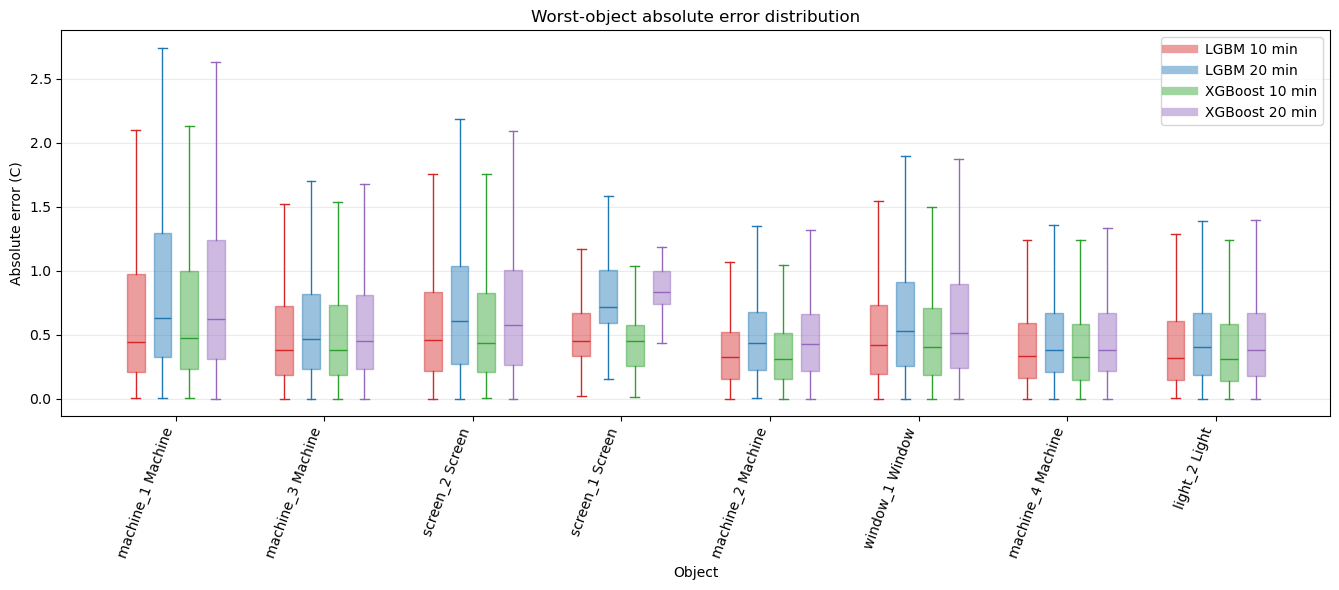

In [ ]:
N_OBJECTS_TO_COMPARE = 8
object_metrics = metric_summary(tuned_test_predictions, ['model', 'target_minutes', 'horizon', 'object_id', 'label'])
object_rank = (
    object_metrics
    .groupby(['object_id', 'label'], as_index=False)['rmse']
    .mean()
    .sort_values('rmse', ascending=False)
)
objects_to_plot = object_rank['object_id'].head(N_OBJECTS_TO_COMPARE).tolist()
display(object_rank.head(N_OBJECTS_TO_COMPARE))

plot_errors = tuned_test_predictions[tuned_test_predictions['object_id'].isin(objects_to_plot)].copy()
plot_errors['absolute_error'] = plot_errors['error'].abs()
plot_errors['object_label'] = plot_errors['object_id'].astype(str) + ' ' + plot_errors['label'].astype(str)
object_label_order = [
    f"{str(row.object_id)} {str(row.label)}"
    for row in object_rank[object_rank['object_id'].isin(objects_to_plot)].itertuples()
]
series_order = [(model_name, float(target_minutes)) for model_name in MODEL_ORDER for target_minutes in TARGET_MINUTES_LIST]
offsets = np.linspace(-0.27, 0.27, len(series_order))
base_positions = np.arange(len(object_label_order))

fig, ax = plt.subplots(figsize=(13.5, 6.0))
legend_handles = []
for offset, (model_name, target_minutes) in zip(offsets, series_order):
    data = []
    positions = []
    for base_pos, object_label in zip(base_positions, object_label_order):
        part = plot_errors[
            (plot_errors['object_label'] == object_label)
            & (plot_errors['model'] == model_name)
            & (plot_errors['target_minutes'] == target_minutes)
        ]
        if part.empty:
            continue
        data.append(part['absolute_error'].to_numpy())
        positions.append(base_pos + offset)
    if not data:
        continue
    color = MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777')
    box = ax.boxplot(data, positions=positions, widths=0.12, patch_artist=True, showfliers=False)
    for patch in box['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color)
    for element in ['whiskers', 'caps', 'medians']:
        for item in box[element]:
            item.set_color(color)
    legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=6, alpha=0.45, label=f'{model_name} {target_minutes:g} min'))

ax.set_xticks(base_positions)
ax.set_xticklabels(object_label_order, rotation=70, ha='right')
ax.set_title('Worst-object absolute error distribution')
ax.set_xlabel('Object')
ax.set_ylabel('Absolute error (C)')
ax.grid(axis='y', alpha=0.25)
ax.legend(handles=legend_handles, loc='best')
fig.tight_layout()


## Prediction Timeline

This section plots tuned predictions over time for each object and date, and saves all generated timeline figures.

Ground truth is shown with a rolling mean for visual readability. The y-axis scale is fixed across figures so temperature levels can be compared between objects and dates. A small sample of figures is displayed in the notebook preview.


In [ ]:
TIMELINE_OBJECT_IDS = sorted(tuned_test_predictions['object_id'].dropna().unique())
GT_SMOOTH_WINDOW = 5
MAX_LINE_GAP_MINUTES = 60.0
TIMELINE_PREVIEW_COUNT = 6
TIMELINE_OUTPUT_DIR = FIGURE_OUTPUT_DIR / 'prediction_timeline'
TIMELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def safe_plot_name(value):
    return ''.join(ch if ch.isalnum() or ch in ('_', '-') else '_' for ch in str(value)).strip('_')


def add_plot_segments(df, time_col, max_gap_minutes):
    df = df.sort_values(time_col).copy()
    gap = df[time_col].diff().dt.total_seconds().div(60)
    return df.assign(_plot_segment=gap.gt(max_gap_minutes).fillna(False).cumsum())


def smooth_gt(df, value_col='target_temp', output_col='target_temp_plot', window=5):
    df = df.sort_values('target_timestamp').copy()
    df[output_col] = df[value_col].rolling(window=window, center=True, min_periods=1).mean()
    return df


plot_df = tuned_test_predictions.copy()
plot_df['target_timestamp'] = pd.to_datetime(plot_df['target_timestamp'])
y_min = plot_df[['target_temp', 'prediction']].min().min()
y_max = plot_df[['target_temp', 'prediction']].max().max()
y_pad = max((y_max - y_min) * 0.05, 0.2)
fixed_ylim = (y_min - y_pad, y_max + y_pad)

plot_tasks = []
for object_id in TIMELINE_OBJECT_IDS:
    object_df = plot_df[plot_df['object_id'] == object_id].copy()
    for target_date, day_df in object_df.groupby(object_df['target_timestamp'].dt.date):
        for model_name, model_day in day_df.groupby('model'):
            plot_tasks.append((object_id, target_date, model_name, day_df, model_day))

rng = np.random.default_rng(RANDOM_STATE)
preview_indices = set(rng.choice(len(plot_tasks), size=min(TIMELINE_PREVIEW_COUNT, len(plot_tasks)), replace=False).tolist()) if plot_tasks else set()
saved_timeline_rows = []

for plot_index, (object_id, target_date, model_name, day_df, model_day) in enumerate(plot_tasks):
    label = day_df['label'].mode().iloc[0] if not day_df['label'].mode().empty else ''
    gt_df = (
        day_df[['target_timestamp', 'target_temp']]
        .drop_duplicates()
        .groupby('target_timestamp', as_index=False)['target_temp']
        .median()
    )
    gt_df = smooth_gt(gt_df, window=GT_SMOOTH_WINDOW)
    gt_df = add_plot_segments(gt_df, 'target_timestamp', MAX_LINE_GAP_MINUTES)

    fig, ax = plt.subplots(figsize=(13, 4.8))
    for segment_id, segment in gt_df.groupby('_plot_segment'):
        ax.plot(
            segment['target_timestamp'],
            segment['target_temp_plot'],
            color='black',
            linewidth=2.0,
            label=f'GT rolling mean ({GT_SMOOTH_WINDOW})' if segment_id == gt_df['_plot_segment'].min() else None,
        )
    for target_minutes, part in model_day.groupby('target_minutes'):
        part = (
            part.groupby('target_timestamp', as_index=False)
            .agg(prediction=('prediction', 'median'))
            .sort_values('target_timestamp')
        )
        part = add_plot_segments(part, 'target_timestamp', MAX_LINE_GAP_MINUTES)
        first_segment = part['_plot_segment'].min()
        for segment_id, segment in part.groupby('_plot_segment'):
            ax.plot(
                segment['target_timestamp'],
                segment['prediction'],
                color=MODEL_HORIZON_COLORS.get((model_name, float(target_minutes)), '#777777'),
                linewidth=1.5,
                label=f'{target_minutes:g} min prediction' if segment_id == first_segment else None,
            )
    ax.set_ylim(*fixed_ylim)
    ax.set_title(f'{target_date} | {object_id} {label} | {model_name}')
    ax.set_xlabel('Target timestamp')
    ax.set_ylabel('Temperature (C)')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    fig.autofmt_xdate(rotation=25)
    fig.tight_layout()

    output_png = TIMELINE_OUTPUT_DIR / f"{target_date}_{safe_plot_name(object_id)}_{safe_plot_name(model_name)}.png"
    fig.savefig(output_png, dpi=160)
    saved_timeline_rows.append({
        'object_id': object_id,
        'label': label,
        'target_date': target_date,
        'model': model_name,
        'output_png': str(output_png),
    })
    if plot_index in preview_indices:
        display(fig)
    plt.close(fig)

saved_timeline_table = pd.DataFrame(saved_timeline_rows)
print(f'saved timeline figures: {len(saved_timeline_table):,}')
display(saved_timeline_table.head(20))
